In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from pyparsing import alphas
from seaborn import lineplot

df = pd.read_csv('data/netflix_titles.csv')
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [2]:
print(df.info())
df.sample(5)

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2914,s2915,Movie,Isi & Ossi,Oliver Kienle,"Lisa Vicari, Dennis Mojen, Walid Al-Atiyat, Ch...",Germany,"February 14, 2020",2020,TV-MA,113 min,"Comedies, International Movies, Romantic Movies",A billionaire's daughter fakes a relationship ...
3673,s3674,TV Show,One Spring Night,NaN,"Han Ji-min, Jung Hae-in, Kim Jun-han, Yim Sung...",South Korea,"July 12, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...","When Lee Jeong-in and Yu Ji-ho meet, something..."
8447,s8448,Movie,The Pass,Ben A. Williams,"Russell Tovey, Arinzé Kene, Lisa McGrillis, Ni...",United Kingdom,"January 1, 2019",2016,NR,87 min,"Dramas, Independent Movies, LGBTQ Movies",The lives and careers of two professional socc...
2026,s2027,Movie,Poshter Girl,Sameer Patil,"Sonalee Kulkarni, Hrishikesh Joshi, Jitendra J...",India,"September 10, 2020",2016,TV-14,138 min,"Comedies, Dramas, International Movies","In a town infamous for female infanticide, a y..."
4841,s4842,TV Show,November 13: Attack on Paris,NaN,NaN,France,"June 1, 2018",2018,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...",Survivors and first responders share personal ...


In [3]:
df['director'].value_counts()

director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Peter Hewitt                1
Mozez Singh                 1
Name: count, Length: 4528, dtype: int64

In [4]:
# 异常值处理
df[['director', 'cast','country']] = df[['director', 'cast','country']].fillna('Unknown')
df = df.dropna()

In [5]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [8]:
df['type'] = df['type'].astype('category')

In [11]:
df['date_added'] = df['date_added'].astype('datetime64[ns]')

In [18]:
df['rating'] = df['rating'].astype('category')

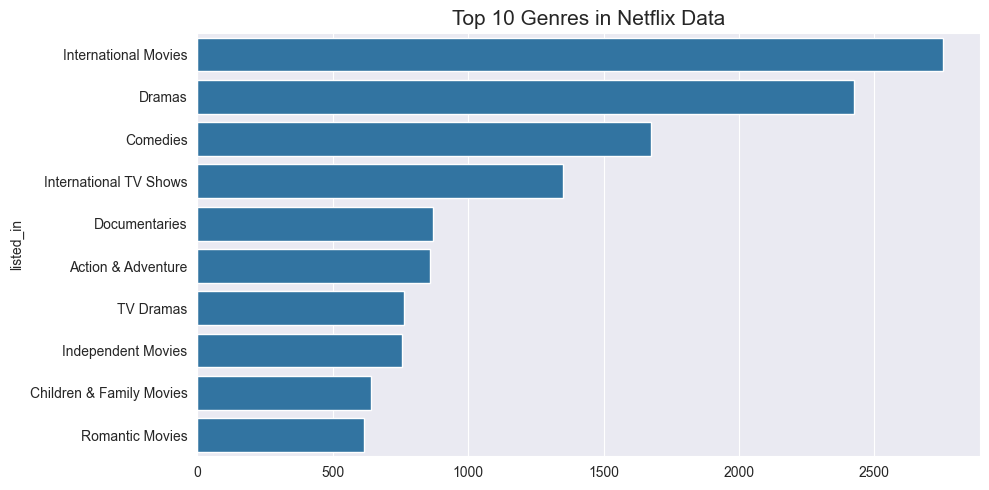

In [52]:
# 看看奈飞 Top 10 影视种类
genre_series = df['listed_in'].str.split(', ')
# 每一个值的列表转为值
genres_exploded = genre_series.explode()
genres_cnt = genres_exploded.value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y= genres_cnt.index, x=genres_cnt.values)
plt.title('Top 10 Genres in Netflix Data',fontsize=15)
plt.tight_layout()
plt.show()

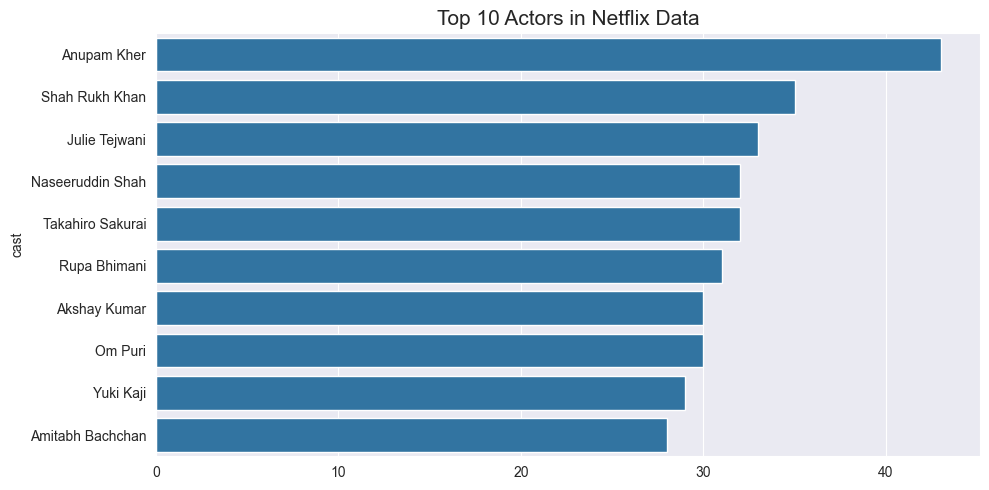

In [69]:
# 看看奈飞数据中出现频率较高的演员有哪些
cast_series = df['cast'].str.split(', ')

cast_explode = cast_series.explode()
cast_cnt = cast_explode.value_counts()
cast_cnt = cast_cnt.drop('Unknown')

cast_cnt = cast_cnt.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=cast_cnt.values,y=cast_cnt.index)
plt.title('Top 10 Actors in Netflix Data',fontsize=15)
plt.tight_layout()
plt.show()

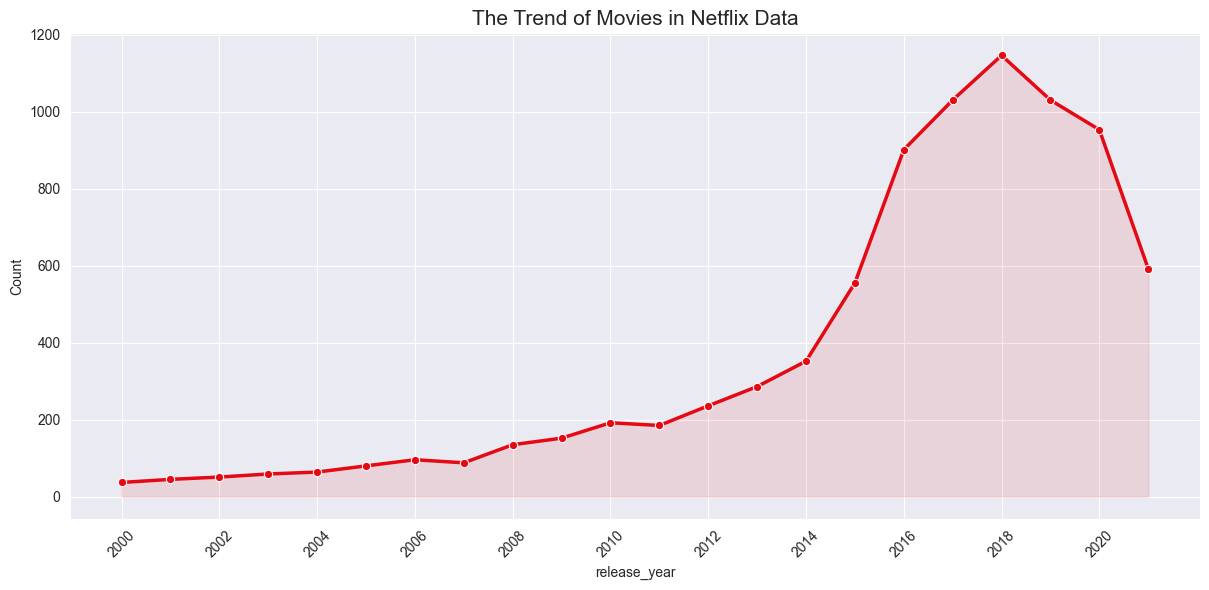

In [101]:
# 统计 2000年 ～ 2021年 奈飞上线影视数和年份的关系
year_cnt = df[df['release_year'] >= 2000]['release_year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_cnt.index, y=year_cnt.values,
             marker='o', color='#E50914', linewidth=2.5)
plt.fill_between(year_cnt.index, year_cnt.values, color='#E50914', alpha=0.1)

plt.xticks(range(2000, 2022, 2)) # 每两年显示一个刻度
plt.xticks(rotation=45)
plt.title('The Trend of Movies in Netflix Data',fontsize=15)
plt.tight_layout()
plt.ylabel('Count')
plt.show()

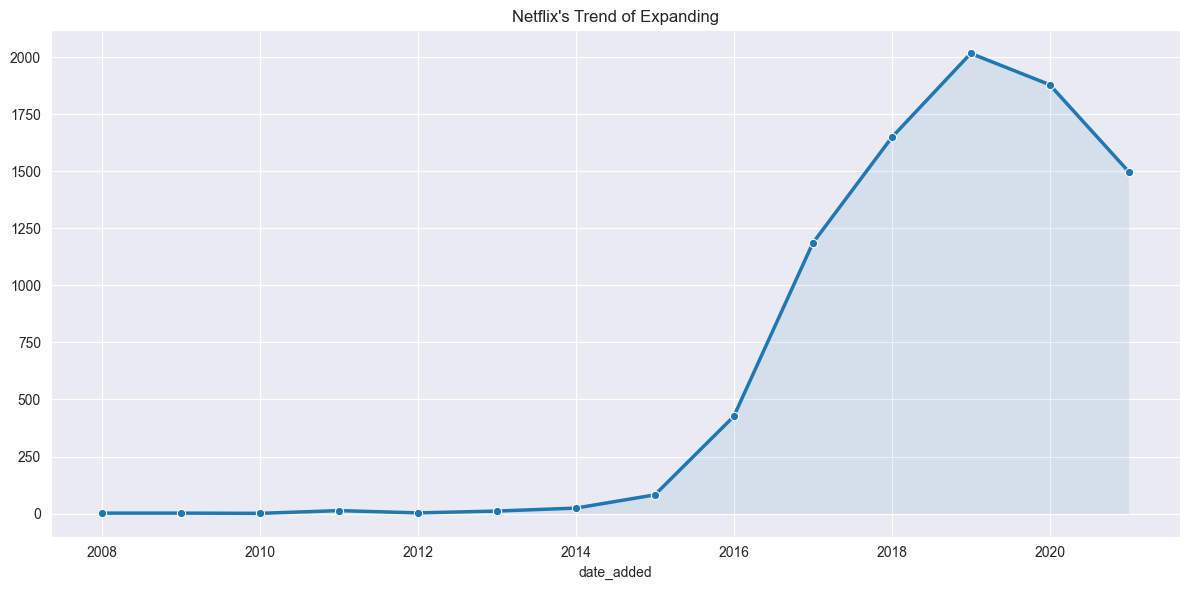

In [155]:
# 根据添加日期查看奈飞近期在影视剧类扩张程度
res = df['date_added'].dt.year.value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=res.index, y=res.values,
             marker='o',linewidth=2.5)
# 着色
plt.fill_between(res.index,res.values,alpha=0.1)
plt.title("Netflix's Trend of Expanding")
plt.tight_layout()
plt.show()

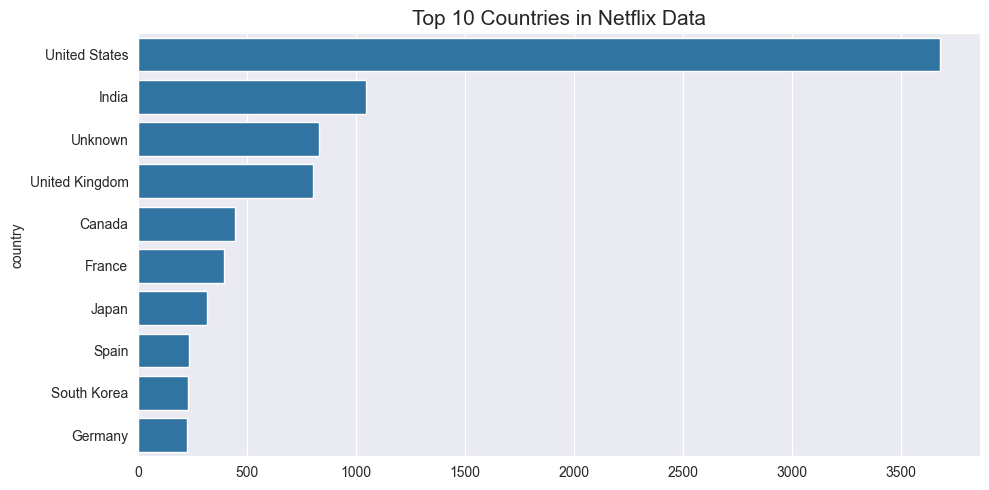

In [172]:
# 在奈飞中Top 10 出产量国家
country_count = df['country'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=country_count.values, y=country_count.index)
plt.title('Top 10 Countries in Netflix Data',fontsize=15)
plt.tight_layout()
plt.show()

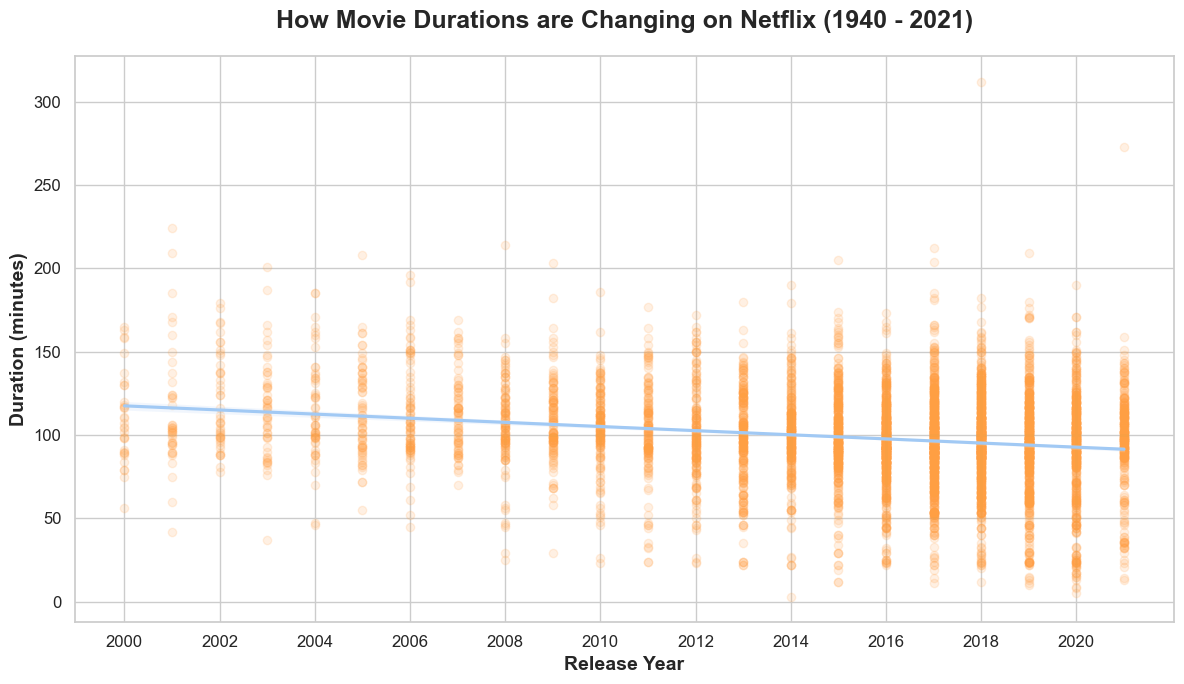

In [209]:
movie = df[df['type'] == 'Movie']
# 研究电影时长随着时间推移的变化
movie['movie_minutes'] = movie['duration'].str.split(' ').str[0].astype('int32')
movie = movie[movie['release_year'] >= 2000]
# 箱型图
plt.figure(figsize=(12, 7))
# 设置主题
sns.set_theme(style="whitegrid", palette="pastel")

sns.regplot(data=movie,x=movie['release_year'],y= movie['movie_minutes'],
            scatter_kws={'alpha': 0.15, 'color': '#FF9F43'})
plt.title('How Movie Durations are Changing on Netflix (1940 - 2021)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Release Year', fontsize=14, fontweight='bold')
plt.ylabel('Duration (minutes)', fontsize=14, fontweight='bold')

# 5. 设置 X 轴刻度，让年份更清晰
plt.xticks(range(2000, 2022,2), rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# 6. 自动调整布局，防止标签被切掉
plt.tight_layout()

plt.show()

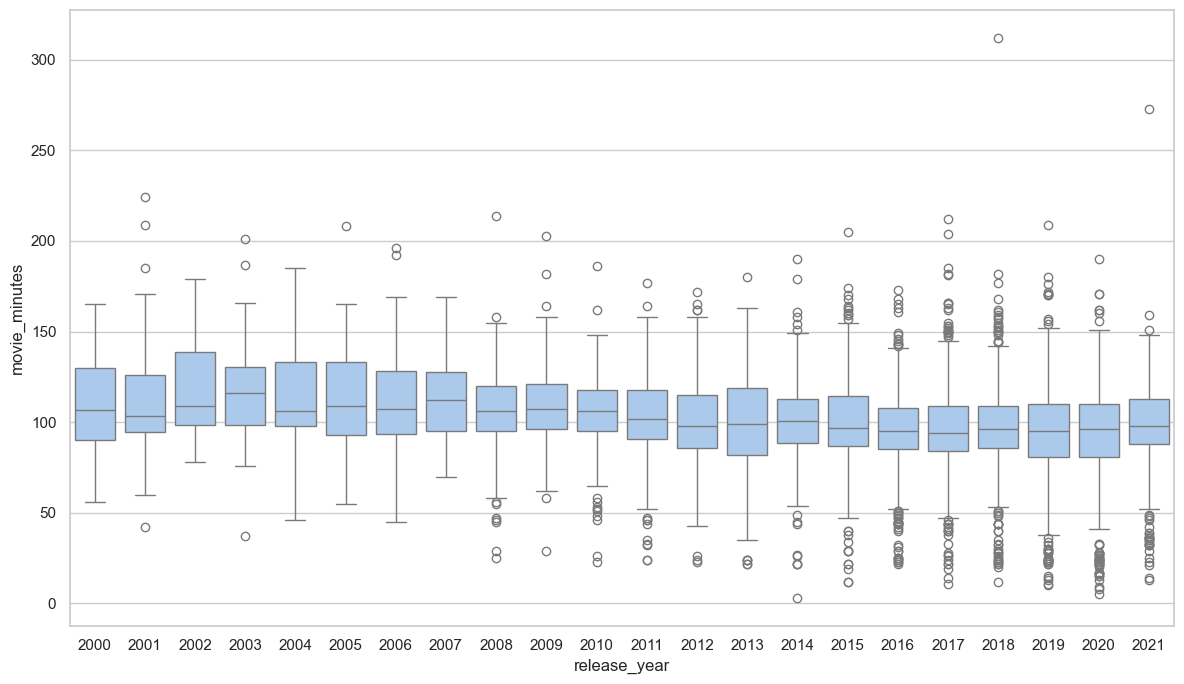

In [212]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=movie,x=movie['release_year'],y= movie['movie_minutes'])
plt.tight_layout()
plt.show()